# Week 02 - Seq2Seq with Attention on Multi30k (German to English)

**Model file:** `week02_seq2seq_attention.py`
**Benchmark dataset:** Multi30k - 29,000 German/English sentence pairs that
describe photos. It is the standard small machine-translation benchmark, so a
full experiment finishes in a few minutes.

## What we do here

The `.py` file implements the attention of this week **by hand**, so the
equations of the lecture notes and the code line up one to one:

| Lecture | `attn_type` | score function |
|---|---|---|
| 4.3.3 Bahdanau (additive) | `"bahdanau"` | $e_{ij} = v_a^\top \tanh(W_a s_{i-1} + U_a h_j)$ |
| 5.3.2 Luong, dot | `"luong-dot"` | $h_t^\top \bar h_s$ |
| 5.3.2 Luong, general | `"luong-general"` | $h_t^\top W_a \bar h_s$ |
| 5.3.2 Luong, concat | `"luong-concat"` | $v_a^\top \tanh(W_a[h_t; \bar h_s])$ |
| week 3 (library) | `"mha"` | scaled dot product, several heads (`nn.MultiheadAttention`) |
| 1-3 baseline | `"none"` | no attention: one fixed context vector $c$ |

## What you will learn

1. How to build a word vocabulary and pad a batch of sentences.
2. How teacher forcing during training differs from greedy decoding at test time.
3. How to score a translation model with **BLEU** and **perplexity**, and why the
   reference you compare against changes the number.
4. Whether attention really removes the fixed-vector bottleneck - measured as
   BLEU per sentence length, against a no-attention baseline.
5. How the five score functions and the two wirings (Bahdanau vs Luong) compare
   on the same data.
6. What beam search and length normalisation do to the output.
7. How to read an attention map - and why the head-averaged map that
   `nn.MultiheadAttention` returns by default is not the $\alpha_{ij}$ of week 2.

## Runtime

About 15-20 minutes on a GPU with the settings below. To make it shorter,
lower `EPOCHS`, `COMPARE_PAIRS` and `COMPARE_EPOCHS` in the configuration cell.

## 1. Setup

In [1]:
import gzip
import importlib
import math
import re
import shutil
import sys
import time
import urllib.request
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import common_eval
import week02_seq2seq_attention as w2

importlib.reload(w2)
importlib.reload(common_eval)

print("model file loaded:", w2.__file__)
print("attention types available:", w2.ATTENTION_TYPES)

model file loaded: /home/jovyan/lecture-advanceddeeplearning/week02_seq2seq_attention.py
attention types available: ('bahdanau', 'luong-dot', 'luong-general', 'luong-concat', 'mha', 'none')


In [2]:
# --- Notebook configuration -------------------------------------------------
SEED = 42
DATA_DIR = Path("./data/multi30k")

MIN_FREQ = 2          # a word must appear this often to get its own id
MAX_LEN_TRAIN = 30    # drop long pairs from train/valid only - the TEST split
                      # keeps every sentence, otherwise the length study in
                      # section 6.4 would have nothing long to look at
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
CLIP = 1.0            # gradient clipping value (lecture 1 section 2.3)

ATTENTION = "bahdanau"   # the model we train in sections 3-6
EMB_DIM = 256
HID_DIM = 256
NUM_HEADS = 8            # only used by attn_type="mha"

# Section 7 trains one model per attention type. To keep that affordable it
# uses a subset of the training pairs and fewer epochs.
COMPARE_PAIRS = 8000
COMPARE_EPOCHS = 3

BEAM_SENTENCES = 300     # how many test sentences to decode with beam search

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

w2.set_seed(SEED)
w2.DEVICE = DEVICE
print(f"device: {DEVICE}")

device: cuda


## 2. Data: the Multi30k benchmark

The official files live on GitHub as small gzip files. We download them once
into `./data/multi30k`. The splits are the standard ones:

* `train` - 29,000 pairs
* `val` - 1,014 pairs
* `test_2016_flickr` - 1,000 pairs (the usual test set for this benchmark)

In [3]:
BASE_URL = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw"
FILES = {
    "train": ["train.de", "train.en"],
    "valid": ["val.de", "val.en"],
    "test": ["test_2016_flickr.de", "test_2016_flickr.en"],
}


def download_multi30k(data_dir: Path):
    """Download and unzip the Multi30k text files if they are not there yet."""
    data_dir.mkdir(parents=True, exist_ok=True)
    for names in FILES.values():
        for name in names:
            target = data_dir / name
            if target.exists():
                continue
            url = f"{BASE_URL}/{name}.gz"
            gz_path = data_dir / f"{name}.gz"
            print("downloading", url)
            urllib.request.urlretrieve(url, gz_path)
            with gzip.open(gz_path, "rb") as source, open(target, "wb") as out:
                shutil.copyfileobj(source, out)
            gz_path.unlink()
    print("data ready in", data_dir.resolve())


download_multi30k(DATA_DIR)

downloading https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.de.gz
downloading https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/train.en.gz
downloading https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.de.gz
downloading https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/val.en.gz
downloading https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/test_2016_flickr.de.gz
downloading https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/test_2016_flickr.en.gz
data ready in /home/jovyan/lecture-advanceddeeplearning/data/multi30k


In [4]:
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", re.UNICODE)


def tokenize(text: str):
    """Lowercase the sentence and split it into words and punctuation marks.

    A real system would use a sub-word tokenizer (BPE). A simple word split is
    enough here and is easy to read.
    """
    return TOKEN_PATTERN.findall(text.lower())


def read_split(name: str, max_len=None):
    """Return a list of (german tokens, english tokens) pairs.

    max_len=None keeps every sentence. We only trim the training and validation
    splits; the test split stays complete so that section 6.4 can measure BLEU
    against sentence length.
    """
    de_file, en_file = FILES[name]
    de_lines = (DATA_DIR / de_file).read_text(encoding="utf-8").splitlines()
    en_lines = (DATA_DIR / en_file).read_text(encoding="utf-8").splitlines()
    pairs = []
    for de_line, en_line in zip(de_lines, en_lines):
        source = tokenize(de_line)
        target = tokenize(en_line)
        if not source or not target:
            continue
        if max_len is not None and (len(source) > max_len or len(target) > max_len):
            continue
        pairs.append((source, target))
    return pairs


train_pairs = read_split("train", MAX_LEN_TRAIN)
valid_pairs = read_split("valid", MAX_LEN_TRAIN)
test_pairs = read_split("test")            # every test sentence, no length filter

print(f"train: {len(train_pairs)}   valid: {len(valid_pairs)}   test: {len(test_pairs)}")
lengths = [len(s) for s, _ in test_pairs]
print(f"test source length: min {min(lengths)}  median {sorted(lengths)[len(lengths) // 2]}"
      f"  max {max(lengths)}")
print("\nexample pair:")
print("  DE:", " ".join(train_pairs[0][0]))
print("  EN:", " ".join(train_pairs[0][1]))

train: 28908   valid: 1010   test: 1000
test source length: min 5  median 11  max 35

example pair:
  DE: zwei junge weiße männer sind im freien in der nähe vieler büsche .
  EN: two young , white males are outside near many bushes .


### Building the vocabulary

The model file uses one embedding table for the encoder and one for the
decoder, but both are created with the same `VOCAB_SIZE`. The simplest way to
reuse it is a **shared vocabulary** that holds German and English words together.

Four special ids are reserved:

| id | token | meaning |
|---|---|---|
| 0 | `<pad>` | filler so that every sentence in a batch has the same length |
| 1 | `<bos>` | "begin of sentence", the first decoder input |
| 2 | `<eos>` | "end of sentence", tells the decoder to stop |
| 3 | `<unk>` | any word that is too rare to get its own id |

In [5]:
PAD, BOS, EOS = w2.PAD, w2.BOS, w2.EOS   # 0, 1, 2 - defined in the .py file
UNK = 3

counter = Counter()
for source, target in train_pairs:
    counter.update(source)
    counter.update(target)

itos = ["<pad>", "<bos>", "<eos>", "<unk>"]
itos += [word for word, count in counter.most_common() if count >= MIN_FREQ]
stoi = {word: index for index, word in enumerate(itos)}
VOCAB_SIZE = len(itos)

print(f"vocabulary size: {VOCAB_SIZE} (words seen at least {MIN_FREQ} times)")
print("most common words:", itos[4:14])


def encode(tokens):
    """Turn a list of words into a list of ids (unknown words become <unk>)."""
    return [stoi.get(token, UNK) for token in tokens]


# How many words are replaced by <unk>? A high number means the vocabulary is too small.
for name, pairs in [("train", train_pairs), ("test", test_pairs)]:
    total = sum(len(s) + len(t) for s, t in pairs)
    unknown = sum(sum(1 for tok in s + t if tok not in stoi) for s, t in pairs)
    print(f"<unk> rate on the {name} set: {100 * unknown / total:.2f} %")

vocabulary size: 13559 (words seen at least 2 times)
most common words: ['.', 'a', 'in', 'ein', 'einem', ',', 'the', 'eine', 'und', 'mit']
<unk> rate on the train set: 1.64 %
<unk> rate on the test set: 2.45 %


In [6]:
class TranslationDataset(Dataset):
    """Stores id sequences: source, decoder input and decoder target.

    reverse_source flips the source word order (Sutskever et al., 2014).
    """

    def __init__(self, pairs, reverse_source=False):
        self.data = []
        for source, target in pairs:
            tokens = source[::-1] if reverse_source else source
            source_ids = encode(tokens) + [EOS]
            target_in = [BOS] + encode(target)      # what the decoder reads
            target_out = encode(target) + [EOS]     # what the decoder must predict
            self.data.append((source_ids, target_in, target_out))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index]


def collate(batch):
    """Pad a list of samples into rectangular tensors."""
    source_max = max(len(s) for s, _, _ in batch)
    target_max = max(len(t) for _, t, _ in batch)

    source = torch.full((len(batch), source_max), PAD, dtype=torch.long)
    target_in = torch.full((len(batch), target_max), PAD, dtype=torch.long)
    target_out = torch.full((len(batch), target_max), PAD, dtype=torch.long)

    for row, (s, t_in, t_out) in enumerate(batch):
        source[row, :len(s)] = torch.tensor(s)
        target_in[row, :len(t_in)] = torch.tensor(t_in)
        target_out[row, :len(t_out)] = torch.tensor(t_out)

    # True where the position is padding; attention must ignore those positions.
    source_pad = source.eq(PAD)
    return source, target_in, target_out, source_pad


def make_loaders(reverse_source=False, train_subset=None, batch_size=BATCH_SIZE):
    pairs = train_pairs if train_subset is None else train_pairs[:train_subset]
    train = DataLoader(TranslationDataset(pairs, reverse_source), batch_size=batch_size,
                       shuffle=True, collate_fn=collate)
    valid = DataLoader(TranslationDataset(valid_pairs, reverse_source),
                       batch_size=batch_size, shuffle=False, collate_fn=collate)
    test = DataLoader(TranslationDataset(test_pairs, reverse_source), batch_size=64,
                      shuffle=False, collate_fn=collate)
    return train, valid, test


train_loader, valid_loader, test_loader = make_loaders()
test_dataset = TranslationDataset(test_pairs)
DECODE_MAX_LEN = max(len(t) for _, t in test_pairs) + 2

source, target_in, target_out, source_pad = next(iter(train_loader))
print("batch shapes:", source.shape, target_in.shape, target_out.shape)
print("decode max length:", DECODE_MAX_LEN)

batch shapes: torch.Size([128, 26]) torch.Size([128, 25]) torch.Size([128, 25])
decode max length: 35


## 3. Model

The classes inside the `.py` file read module-level settings such as
`VOCAB_SIZE` when they are created, so we set those **before** we build the
model. `attn_type` picks the score function; `wiring` picks where the context
vector enters the decoder:

* `wiring="bahdanau"`: query is $s_{i-1}$, the context goes **into** the RNN,
  and the output layer reads $g(y_{i-1}, s_i, c_i)$.
* `wiring="luong"`: the RNN runs first, the query is the current state $h_t$,
  and the context is mixed in afterwards: $\tilde h_t = \tanh(W_c[c_t; h_t])$.

Leaving `wiring=None` picks the one the corresponding paper used.

In [7]:
# Tell the model file about the new vocabulary and a bigger hidden size.
w2.VOCAB_SIZE = VOCAB_SIZE
w2.EMB_DIM = EMB_DIM
w2.HID_DIM = HID_DIM
w2.NUM_HEADS = NUM_HEADS
w2.LR = LR

model = w2.Seq2Seq(attn_type=ATTENTION).to(DEVICE)
print(model.describe())
print()
print(model.decoder.attn)

attention=bahdanau  wiring=bahdanau  input_feeding=False  memory_dim=512  context_dim=512  params=22,745,847

BahdanauAttention(
  (W_a): Linear(in_features=256, out_features=256, bias=False)
  (U_a): Linear(in_features=512, out_features=256, bias=False)
  (v_a): Linear(in_features=256, out_features=1, bias=False)
)


In [8]:
# The three lines of Bahdanau attention, on one real batch.
source, target_in, target_out, source_pad = next(iter(train_loader))
source, source_pad = source.to(DEVICE), source_pad.to(DEVICE)

with torch.no_grad():
    memory, hidden = model.encoder(source)              # h_1 .. h_Tx  (annotations)
    attn = model.decoder.attn
    cache = attn.precompute(memory)                     # U_a h_j, computed once
    query = hidden[-1]                                  # s_{i-1}
    energy = attn.v_a(torch.tanh(cache + attn.W_a(query).unsqueeze(1))).squeeze(-1)
    alpha_masked = w2.masked_softmax(energy, source_pad)
    alpha_unmasked = w2.masked_softmax(energy, None)

print("annotations h_j :", tuple(memory.shape), "  (batch, source length, 2n)")
print("energies e_ij   :", tuple(energy.shape))
print("alpha rows sum to 1:", alpha_masked.sum(1)[:3].tolist())

row = int(source_pad.sum(1).argmax())                   # the most padded sentence
pad_from = int((~source_pad[row]).sum())
print(f"\nsentence {row} has {source_pad[row].sum().item()} padding positions "
      f"(real tokens: {pad_from})")
print(f"  probability given to padding WITH the mask   : "
      f"{alpha_masked[row, pad_from:].sum().item():.6f}")
print(f"  probability given to padding WITHOUT the mask: "
      f"{alpha_unmasked[row, pad_from:].sum().item():.6f}")
print("\nForgetting the mask hands attention to words that are not there.")

annotations h_j : (128, 25, 512)   (batch, source length, 2n)
energies e_ij   : (128, 25)
alpha rows sum to 1: [1.0000001192092896, 1.0, 1.0]

sentence 73 has 19 padding positions (real tokens: 6)
  probability given to padding WITH the mask   : 0.000000
  probability given to padding WITHOUT the mask: 0.756068

Forgetting the mask hands attention to words that are not there.


## 4. Training

During training we use **teacher forcing**: at every step the decoder reads the
*correct* previous word, not its own guess. This makes training stable and fast.
At test time the correct word is unknown, so the decoder must read its own
output - that is greedy decoding in section 5.

The loss ignores padding positions (`ignore_index=PAD`), otherwise the model
would get a good score just by predicting `<pad>` everywhere.

In [9]:
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over the data. Pass optimizer=None for evaluation only."""
    is_training = optimizer is not None
    model.train(is_training)

    loss_sum, token_count, correct = 0.0, 0, 0
    for source, target_in, target_out, source_pad in loader:
        source = source.to(DEVICE)
        target_in = target_in.to(DEVICE)
        target_out = target_out.to(DEVICE)
        source_pad = source_pad.to(DEVICE)

        with torch.set_grad_enabled(is_training):
            logits = model(source, target_in, source_pad)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), target_out.reshape(-1))

        if is_training:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            optimizer.step()

        # Count only the real (non padding) target words.
        mask = target_out != PAD
        n_tokens = int(mask.sum())
        loss_sum += loss.item() * n_tokens
        token_count += n_tokens
        correct += int((logits.argmax(-1)[mask] == target_out[mask]).sum())

    return loss_sum / token_count, correct / token_count


def fit(model, train_loader, valid_loader, epochs, lr=LR, verbose=True):
    """Train and keep the weights of the best validation epoch."""
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "valid_loss": [], "valid_acc": []}
    best_loss, best_state = float("inf"), None

    for epoch in range(1, epochs + 1):
        train_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_acc = run_epoch(model, valid_loader, criterion, None)
        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            marker = "  <- best so far"
        else:
            marker = ""
        if verbose:
            print(f"epoch {epoch:2d}/{epochs}  train_loss={train_loss:.4f}  "
                  f"valid_loss={valid_loss:.4f}  valid_ppl={math.exp(valid_loss):.2f}  "
                  f"valid_token_acc={valid_acc:.4f}{marker}")
    model.load_state_dict(best_state)
    return history, best_loss


criterion = nn.CrossEntropyLoss(ignore_index=PAD)
start_time = time.time()
history, best_valid_loss = fit(model, train_loader, valid_loader, EPOCHS)
print(f"\ntraining time: {time.time() - start_time:.1f} s")
print(f"best validation loss: {best_valid_loss:.4f}")

epoch  1/10  train_loss=3.7136  valid_loss=2.5566  valid_ppl=12.89  valid_token_acc=0.5476  <- best so far
epoch  2/10  train_loss=2.1778  valid_loss=2.0267  valid_ppl=7.59  valid_token_acc=0.6190  <- best so far
epoch  3/10  train_loss=1.5983  valid_loss=1.8344  valid_ppl=6.26  valid_token_acc=0.6452  <- best so far
epoch  4/10  train_loss=1.2432  valid_loss=1.7836  valid_ppl=5.95  valid_token_acc=0.6510  <- best so far
epoch  5/10  train_loss=0.9965  valid_loss=1.7652  valid_ppl=5.84  valid_token_acc=0.6584  <- best so far
epoch  6/10  train_loss=0.8137  valid_loss=1.7942  valid_ppl=6.01  valid_token_acc=0.6569
epoch  7/10  train_loss=0.6668  valid_loss=1.8274  valid_ppl=6.22  valid_token_acc=0.6497
epoch  8/10  train_loss=0.5474  valid_loss=1.8744  valid_ppl=6.52  valid_token_acc=0.6504
epoch  9/10  train_loss=0.4485  valid_loss=1.9336  valid_ppl=6.91  valid_token_acc=0.6483
epoch 10/10  train_loss=0.3686  valid_loss=1.9967  valid_ppl=7.36  valid_token_acc=0.6414

training time: 136

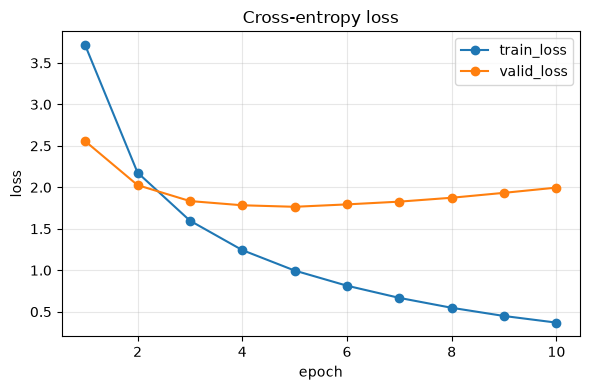

In [10]:
common_eval.plot_curves(history, ["train_loss", "valid_loss"],
                        title="Cross-entropy loss", ylabel="loss")

## 5. Inference: greedy decoding

`w2.greedy_decode` takes the encoder output and produces one word at a time,
always choosing the most likely next word. It stops when every sentence in the
batch has produced `<eos>`. Passing `return_attention=True` also gives back the
attention weights, shaped `(batch, steps, heads, source length)`.

In [11]:
def ids_to_tokens(row):
    """Turn a row of ids back into words, stopping at the first <eos>."""
    words = []
    for index in (row.tolist() if torch.is_tensor(row) else row):
        if index == EOS:
            break
        if index in (PAD, BOS):
            continue
        words.append(itos[index])
    return words


def translate_loader(model, loader, max_len=None):
    """Translate every sentence in a loader. Returns the hypotheses only."""
    max_len = max_len or DECODE_MAX_LEN
    hypotheses = []
    for source, _, _, source_pad in loader:
        source = source.to(DEVICE)
        source_pad = source_pad.to(DEVICE)
        predicted = w2.greedy_decode(model, source, source_pad, max_len=max_len)
        hypotheses.extend(ids_to_tokens(predicted[row]) for row in range(source.size(0)))
    return hypotheses


# Two versions of the reference, because they do NOT give the same BLEU:
#   raw       - the English sentence as it is written in the corpus
#   unkified  - the same sentence after rare words became <unk>
references_raw = [target for _, target in test_pairs]
references_unkified = [[itos[i] for i in encode(target)] for _, target in test_pairs]

start_time = time.time()
test_hypotheses = translate_loader(model, test_loader)
print(f"decoded {len(test_hypotheses)} test sentences in {time.time() - start_time:.1f} s")

decoded 1000 test sentences in 0.3 s


In [12]:
# Print a few translations so we can judge them by eye.
for index in [0, 1, 5, 17, 42]:
    source_tokens, target_tokens = test_pairs[index]
    print(f"[{index}]")
    print("  source (de) :", " ".join(source_tokens))
    print("  reference   :", " ".join(target_tokens))
    print("  model       :", " ".join(test_hypotheses[index]))
    print()

[0]
  source (de) : ein mann mit einem orangefarbenen hut , der etwas anstarrt .
  reference   : a man in an orange hat starring at something .
  model       : a man in an orange hat is looking at something .

[1]
  source (de) : ein boston terrier läuft über saftig - grünes gras vor einem weißen zaun .
  reference   : a boston terrier is running on lush green grass in front of a white fence .
  model       : a boston terrier runs on grass , green grass in front of a white fence .

[5]
  source (de) : ein hell gekleideter mann fotografiert eine gruppe von männern in dunklen anzügen und mit hüten , die um eine frau in einem trägerlosen kleid herum stehen .
  reference   : a man in light colored clothing photographs a group of men wearing dark suits and hats standing around a woman dressed in a strapless gown .
  model       : a man dressed in a light blue uniform standing or singing in a dark - circle with a woman in a dress <unk> dress .

[17]
  source (de) : eine frau in einem grauen 

## 6. Performance evaluation

* **Perplexity** = `exp(cross entropy)`. It says how "surprised" the model is by
  the correct next word. Lower is better; 1.0 would be a perfect model.
* **Token accuracy** is measured with teacher forcing, so it is easier than
  real translation and always looks better than BLEU.
* **BLEU** compares the n-grams of the model output with the reference
  translation and adds a penalty for output that is too short. It is the
  standard score for machine translation. Higher is better (0 to 100).

### 6.1 Which reference? The `<unk>` trap

If we rebuild the reference from the *ids*, every rare word in it has already
become `<unk>` - and the model also writes `<unk>`. Those two `<unk>` tokens
then count as a matching n-gram and BLEU goes up for the wrong reason. The
honest comparison is against the raw corpus sentence.

This is the same effect as the **All** and **No UNK** columns of the Bahdanau
paper (lecture 4.4, observation 1): the gap between the two numbers measures how
much the vocabulary limit costs us, not how good the model is.

In [13]:
test_loss, test_token_acc = run_epoch(model, test_loader, criterion, None)
bleu_raw = common_eval.corpus_bleu(test_hypotheses, references_raw)
bleu_unkified = common_eval.corpus_bleu(test_hypotheses, references_unkified)

print("Multi30k results (German -> English)")
print(f"  test BLEU-4 vs raw reference       : {bleu_raw:.2f}   <- report this one")
print(f"  test BLEU-4 vs <unk>-ified reference: {bleu_unkified:.2f}   "
      f"(+{bleu_unkified - bleu_raw:.2f} for free)")
print(f"  test perplexity                    : {math.exp(test_loss):.2f}")
print(f"  test token accuracy (teacher forced): {test_token_acc:.4f}")

# A single sentence makes the mechanism obvious.
demo_hypothesis = [["a", "man", "in", "a", "<unk>", "shirt"]]
print("\nWhy it happens, on one sentence:")
print(f"  vs ['a','man','in','a','<unk>','shirt'] : "
      f"{common_eval.corpus_bleu(demo_hypothesis, [['a','man','in','a','<unk>','shirt']]):.2f}")
print(f"  vs ['a','man','in','a','plaid','shirt'] : "
      f"{common_eval.corpus_bleu(demo_hypothesis, [['a','man','in','a','plaid','shirt']]):.2f}")

Multi30k results (German -> English)
  test BLEU-4 vs raw reference       : 33.98   <- report this one
  test BLEU-4 vs <unk>-ified reference: 34.32   (+0.34 for free)
  test perplexity                    : 6.46
  test token accuracy (teacher forced): 0.6475

Why it happens, on one sentence:
  vs ['a','man','in','a','<unk>','shirt'] : 100.00
  vs ['a','man','in','a','plaid','shirt'] : 64.35


In [14]:
# BLEU for each n-gram order shows where the model is weak.
# High 1-gram but low 4-gram means: right words, wrong word order.
for order in [1, 2, 3, 4]:
    score = common_eval.corpus_bleu(test_hypotheses, references_raw, max_n=order)
    print(f"  BLEU-{order}: {score:5.2f}")

hypothesis_length = sum(len(h) for h in test_hypotheses)
reference_length = sum(len(r) for r in references_raw)
print(f"\nlength ratio (model / reference): "
      f"{hypothesis_length / reference_length:.3f}   (1.0 is what we want)")

  BLEU-1: 66.00
  BLEU-2: 52.35
  BLEU-3: 42.04
  BLEU-4: 33.98

length ratio (model / reference): 0.986   (1.0 is what we want)


### 6.4 BLEU against sentence length - the bottleneck test

This is the measurement the whole week turns on. Bahdanau's Figure 2 shows the
plain encoder-decoder falling apart as sentences get longer, while the attention
model stays flat. We can reproduce the *shape* of that figure here because the
test split was never length-filtered.

In [15]:
BUCKETS = [(1, 10), (11, 15), (16, 20), (21, 25), (26, 100)]


def bleu_by_length(hypotheses, pairs=None, references=None, buckets=BUCKETS):
    """Corpus BLEU inside each source-length bucket."""
    pairs = pairs if pairs is not None else test_pairs
    references = references if references is not None else references_raw
    rows = []
    for low, high in buckets:
        index = [i for i, (s, _) in enumerate(pairs) if low <= len(s) <= high]
        if not index:
            rows.append((f"{low}-{high}", 0, float("nan")))
            continue
        score = common_eval.corpus_bleu([hypotheses[i] for i in index],
                                        [references[i] for i in index])
        rows.append((f"{low}-{high}", len(index), score))
    return rows


print(f"{'source length':>14}{'sentences':>11}{'BLEU':>8}")
for label, count, score in bleu_by_length(test_hypotheses):
    print(f"{label:>14}{count:>11}{score:>8.2f}")

 source length  sentences    BLEU
          1-10        384   35.24
         11-15        433   35.52
         16-20        137   33.84
         21-25         35   22.12
        26-100         11   22.02


## 7. Comparing attention mechanisms

Now the part that this week is really about. We train one model per attention
type on the same data, with the same seed and the same number of epochs, and
compare them. To keep the cell affordable we use a subset of the training pairs
(`COMPARE_PAIRS`) and few epochs (`COMPARE_EPOCHS`), so the absolute BLEU is
lower than in section 6 - only the *comparison* is meaningful.

The most important row is `none`: that is the plain RNN encoder-decoder with one
fixed context vector, the model attention was invented to beat.

In [16]:
compare_train, compare_valid, compare_test = make_loaders(train_subset=COMPARE_PAIRS)


def run_experiment(attn_type, wiring=None, input_feeding=False, epochs=COMPARE_EPOCHS,
                   loaders=None, label=None, keep_model=False):
    """Train one configuration from scratch and score it on the test split."""
    train_l, valid_l, test_l = loaders or (compare_train, compare_valid, compare_test)
    w2.set_seed(SEED)
    net = w2.Seq2Seq(attn_type=attn_type, wiring=wiring,
                     input_feeding=input_feeding).to(DEVICE)
    _, _ = fit(net, train_l, valid_l, epochs, verbose=False)
    loss, accuracy = run_epoch(net, test_l, criterion, None)
    hypotheses = translate_loader(net, test_l)
    return {
        "label": label or attn_type,
        "attention": attn_type,
        "wiring": net.decoder.wiring,
        "input_feeding": net.decoder.input_feeding,
        "params": sum(p.numel() for p in net.parameters()),
        "ppl": math.exp(loss),
        "token_acc": accuracy,
        "bleu": common_eval.corpus_bleu(hypotheses, references_raw),
        "hypotheses": hypotheses,
        "model": net if keep_model else None,
    }


experiments = []
start_time = time.time()
for attn_type in ["none", "bahdanau", "luong-dot", "luong-general", "luong-concat", "mha"]:
    result = run_experiment(attn_type, keep_model=attn_type in ("bahdanau", "mha"))
    experiments.append(result)
    print(f"  {result['label']:<15} BLEU={result['bleu']:5.2f}  ppl={result['ppl']:6.2f}  "
          f"params={result['params']:,}")
print(f"\ntotal time: {time.time() - start_time:.0f} s")

  none            BLEU=10.41  ppl= 25.12  params=22,548,983
  bahdanau        BLEU=17.47  ppl= 18.25  params=22,745,847
  luong-dot       BLEU= 3.80  ppl= 58.35  params=12,004,855
  luong-general   BLEU= 4.43  ppl= 46.55  params=12,070,135
  luong-concat    BLEU= 9.89  ppl= 31.37  params=12,135,927
  mha             BLEU=16.45  ppl= 19.87  params=19,275,767

total time: 102 s


In [17]:
print(f"{'attention':<15}{'wiring':<11}{'params':>11}{'ppl':>8}{'tok.acc':>9}{'BLEU':>8}")
for result in sorted(experiments, key=lambda r: -r["bleu"]):
    print(f"{result['label']:<15}{result['wiring']:<11}{result['params']:>11,}"
          f"{result['ppl']:>8.2f}{result['token_acc']:>9.4f}{result['bleu']:>8.2f}")

baseline = next(r for r in experiments if r["attention"] == "none")
best = max((r for r in experiments if r["attention"] != "none"), key=lambda r: r["bleu"])
delta = best["bleu"] - baseline["bleu"]
print(f"\nno-attention baseline : {baseline['bleu']:.2f} BLEU")
print(f"best attention model  : {best['bleu']:.2f} BLEU  ({best['label']}, {delta:+.2f})")
print("\nWith so few epochs the ranking among the attention types is noisy - the")
print("differences between the score functions in the Luong paper were also only")
print("one or two BLEU. The comparison that should be clear is attention vs none,")
print("and it should get clearer as sentences get longer (next cell).")

attention      wiring          params     ppl  tok.acc    BLEU
bahdanau       bahdanau    22,745,847   18.25   0.5108   17.47
mha            bahdanau    19,275,767   19.87   0.4963   16.45
none           bahdanau    22,548,983   25.12   0.4457   10.41
luong-concat   luong       12,135,927   31.37   0.4392    9.89
luong-general  luong       12,070,135   46.55   0.3698    4.43
luong-dot      luong       12,004,855   58.35   0.3462    3.80

no-attention baseline : 10.41 BLEU
best attention model  : 17.47 BLEU  (bahdanau, +7.06)

With so few epochs the ranking among the attention types is noisy - the
differences between the score functions in the Luong paper were also only
one or two BLEU. The comparison that should be clear is attention vs none,
and it should get clearer as sentences get longer (next cell).


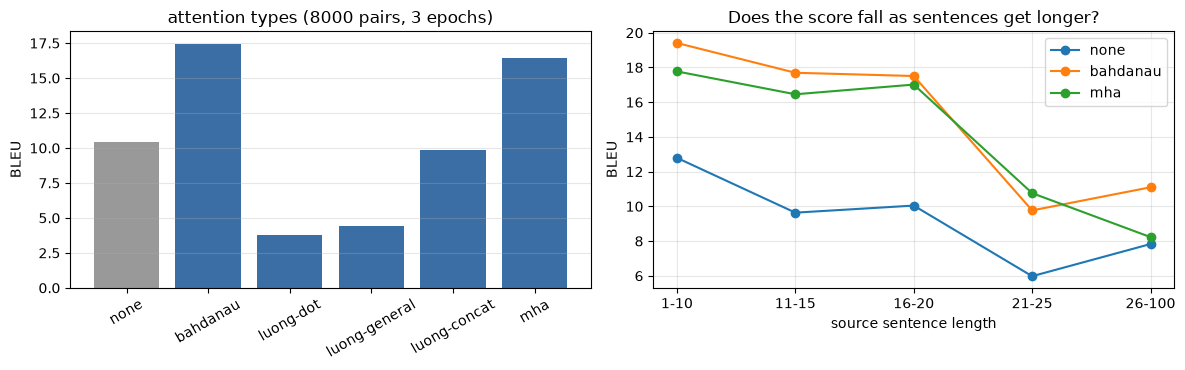

    length            none        bahdanau             mha
      1-10           12.79           19.41           17.77
     11-15            9.64           17.69           16.45
     16-20           10.04           17.51           17.01
     21-25            5.98            9.77           10.76
    26-100            7.83           11.10            8.23


In [18]:
# The bottleneck, drawn: BLEU per length bucket, attention vs no attention.
figure, axes = plt.subplots(1, 2, figsize=(12, 3.8))

labels = [r["label"] for r in experiments]
axes[0].bar(labels, [r["bleu"] for r in experiments],
            color=["#999999"] + ["#3b6ea5"] * (len(experiments) - 1))
axes[0].set_ylabel("BLEU")
axes[0].set_title(f"attention types ({COMPARE_PAIRS} pairs, {COMPARE_EPOCHS} epochs)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

for result in experiments:
    if result["attention"] not in ("none", "bahdanau", "mha"):
        continue
    rows = bleu_by_length(result["hypotheses"])
    axes[1].plot([r[0] for r in rows], [r[2] for r in rows], marker="o",
                 label=result["label"])
axes[1].set_xlabel("source sentence length")
axes[1].set_ylabel("BLEU")
axes[1].set_title("Does the score fall as sentences get longer?")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'length':>10}" + "".join(f"{r['label']:>16}" for r in experiments
                                  if r["attention"] in ("none", "bahdanau", "mha")))
rows_per_model = {r["label"]: bleu_by_length(r["hypotheses"]) for r in experiments
                  if r["attention"] in ("none", "bahdanau", "mha")}
for i, (label, _, _) in enumerate(next(iter(rows_per_model.values()))):
    print(f"{label:>10}" + "".join(f"{rows[i][2]:>16.2f}" for rows in rows_per_model.values()))

### 7.2 The two wirings

Bahdanau and Luong differ in two independent ways: the **score function** and
the **wiring**. Above we changed only the score function. Here we hold the score
function fixed and change the wiring, so the effect of each choice is separated.

In [19]:
wiring_runs = [
    ("bahdanau", "bahdanau", False, "additive / Bahdanau wiring"),
    ("bahdanau", "luong", False, "additive / Luong wiring"),
    ("luong-general", "bahdanau", False, "general / Bahdanau wiring"),
    ("luong-general", "luong", False, "general / Luong wiring"),
    ("luong-general", "luong", True, "general / Luong wiring + input feeding"),
]

wiring_results = []
for attn_type, wiring, feeding, label in wiring_runs:
    result = run_experiment(attn_type, wiring=wiring, input_feeding=feeding, label=label)
    wiring_results.append(result)
    print(f"  {label:<42} BLEU={result['bleu']:5.2f}  ppl={result['ppl']:6.2f}")

  additive / Bahdanau wiring                 BLEU=17.47  ppl= 18.25
  additive / Luong wiring                    BLEU= 9.48  ppl= 31.52
  general / Bahdanau wiring                  BLEU=11.00  ppl= 25.10
  general / Luong wiring                     BLEU= 4.43  ppl= 46.55
  general / Luong wiring + input feeding     BLEU= 4.64  ppl= 45.81


### 7.3 "concat" and "additive" really are the same equation

The lecture notes claim that writing $W_a[h_t; \bar h_s]$ and writing
$W^{(1)} h_t + W^{(2)}\bar h_s$ are the same operation, because a block matrix
times a stacked vector is the sum of the blocks times the parts. Let us check
that on real tensors instead of taking it on faith.

In [20]:
torch.manual_seed(0)
query_dim, mem_dim, attn_dim, source_len = 4, 6, 5, 3

luong_concat = w2.LuongAttention(query_dim, mem_dim, score="concat", attn_dim=attn_dim)
query = torch.randn(2, query_dim)
memory = torch.randn(2, source_len, mem_dim)

# Split the single weight matrix into the two blocks.
W_all = luong_concat.W_a.weight                 # (attn_dim, query_dim + mem_dim)
W_query, W_memory = W_all[:, :query_dim], W_all[:, query_dim:]

bahdanau = w2.BahdanauAttention(query_dim, mem_dim, attn_dim=attn_dim)
with torch.no_grad():
    bahdanau.W_a.weight.copy_(W_query)          # W_a  <- left block
    bahdanau.U_a.weight.copy_(W_memory)         # U_a  <- right block
    bahdanau.v_a.weight.copy_(luong_concat.v_a.weight)

with torch.no_grad():
    _, alpha_concat = luong_concat(query, memory)
    _, alpha_additive = bahdanau(query, memory)

print("Luong  concat  alpha:", [round(v, 6) for v in alpha_concat[0, 0].tolist()])
print("Bahdanau additive alpha:", [round(v, 6) for v in alpha_additive[0, 0].tolist()])
print(f"max difference: {(alpha_concat - alpha_additive).abs().max().item():.2e}")
print("\nSame numbers: 'concatenate then multiply' == 'multiply separately then add'.")

Luong  concat  alpha: [0.317125, 0.387793, 0.295083]
Bahdanau additive alpha: [0.317125, 0.387793, 0.295083]
max difference: 0.00e+00

Same numbers: 'concatenate then multiply' == 'multiply separately then add'.


## 8. Reversing the source sentence

Sutskever et al. reversed the source word order and BLEU went from 25.9 to 30.6.
The lecture explains why: reversing does not change the *average* distance
between a source word and its translation, it changes the *minimum* - the first
words of the two sentences end up next to each other.

We can rerun the same configuration with a reversed source and see which way it
goes on Multi30k. German and English word order is much closer than English and
French, so do not expect the same size of effect.

In [21]:
reversed_loaders = make_loaders(reverse_source=True, train_subset=COMPARE_PAIRS)

forward_run = next(r for r in experiments if r["attention"] == "none")
reversed_run = run_experiment("none", loaders=reversed_loaders,
                              label="none + reversed source")
reversed_attn = run_experiment("bahdanau", loaders=reversed_loaders,
                               label="bahdanau + reversed source")
bahdanau_run = next(r for r in experiments if r["attention"] == "bahdanau")

print(f"{'configuration':<32}{'ppl':>8}{'BLEU':>8}")
for result in [forward_run, reversed_run, bahdanau_run, reversed_attn]:
    print(f"{result['label']:<32}{result['ppl']:>8.2f}{result['bleu']:>8.2f}")

delta_none = reversed_run["bleu"] - forward_run["bleu"]
delta_attention = reversed_attn["bleu"] - bahdanau_run["bleu"]
print(f"\nreversing the source changes BLEU by {delta_none:+.2f} without attention")
print(f"and by {delta_attention:+.2f} with attention.")
print("\nSutskever's argument predicts a larger gain for the model that has to")
print("squeeze the whole sentence into one vector, because that is the model whose")
print("first source word is furthest from its first target word. Check whether the")
print("two numbers above line up with that, and keep in mind that German and")
print("English word order is much closer than English and French, and that these")
print("runs are short - one run is not evidence on its own.")

configuration                        ppl    BLEU
none                               25.12   10.41
none + reversed source             27.53   10.27
bahdanau                           18.25   17.47
bahdanau + reversed source         16.56   21.27

reversing the source changes BLEU by -0.14 without attention
and by +3.80 with attention.

Sutskever's argument predicts a larger gain for the model that has to
squeeze the whole sentence into one vector, because that is the model whose
first source word is furthest from its first target word. Check whether the
two numbers above line up with that, and keep in mind that German and
English word order is much closer than English and French, and that these
runs are short - one run is not evidence on its own.


## 9. Beam search and length normalisation

Greedy decoding commits to the best word at every step. Beam search keeps the
`beam` best partial sentences instead. The score of a sentence is the sum of the
log probabilities, and log probabilities are negative, so **longer sentences
always score worse**. That is why a wider beam can make BLEU *fall*: the search
finds ever shorter outputs. Dividing by the length (`length_norm=1.0`) repairs it.

In [22]:
beam_pairs = test_pairs[:BEAM_SENTENCES]
beam_references = references_raw[:BEAM_SENTENCES]
beam_dataset = TranslationDataset(beam_pairs)


def beam_translate(model, beam, length_norm):
    hypotheses = []
    for index in range(len(beam_dataset)):
        source_ids, _, _ = beam_dataset[index]
        source = torch.tensor([source_ids], device=DEVICE)
        source_pad = source.eq(PAD)
        ids = w2.beam_decode(model, source, source_pad, max_len=DECODE_MAX_LEN,
                             beam=beam, length_norm=length_norm)
        hypotheses.append(ids_to_tokens(ids))
    return hypotheses


greedy_subset = test_hypotheses[:BEAM_SENTENCES]
print(f"{'decoder':<28}{'BLEU':>8}{'avg length':>12}")
print(f"{'greedy':<28}{common_eval.corpus_bleu(greedy_subset, beam_references):>8.2f}"
      f"{sum(len(h) for h in greedy_subset) / len(greedy_subset):>12.2f}")

start_time = time.time()
for beam in [3, 5]:
    for length_norm in [0.0, 1.0]:
        hypotheses = beam_translate(model, beam, length_norm)
        score = common_eval.corpus_bleu(hypotheses, beam_references)
        average = sum(len(h) for h in hypotheses) / len(hypotheses)
        print(f"{f'beam={beam}, length_norm={length_norm}':<28}{score:>8.2f}{average:>12.2f}")
print(f"\n({BEAM_SENTENCES} sentences, {time.time() - start_time:.0f} s)")
print("Watch the average length in the length_norm=0.0 rows.")

decoder                         BLEU  avg length
greedy                         36.09       12.55
beam=3, length_norm=0.0        37.42       12.52
beam=3, length_norm=1.0        36.58       12.89
beam=5, length_norm=0.0        37.60       12.34
beam=5, length_norm=1.0        37.36       12.85

(300 sentences, 12 s)
Watch the average length in the length_norm=0.0 rows.


## 10. Looking inside the attention

Each row of the picture is one output word, each column one input word. A bright
cell means "the decoder used this German word here".

`w2.greedy_decode(..., return_attention=True)` returns weights shaped
`(batch, steps, heads, source length)`. Hand-written attention has one head, so
head 0 *is* $\alpha_{ij}$.

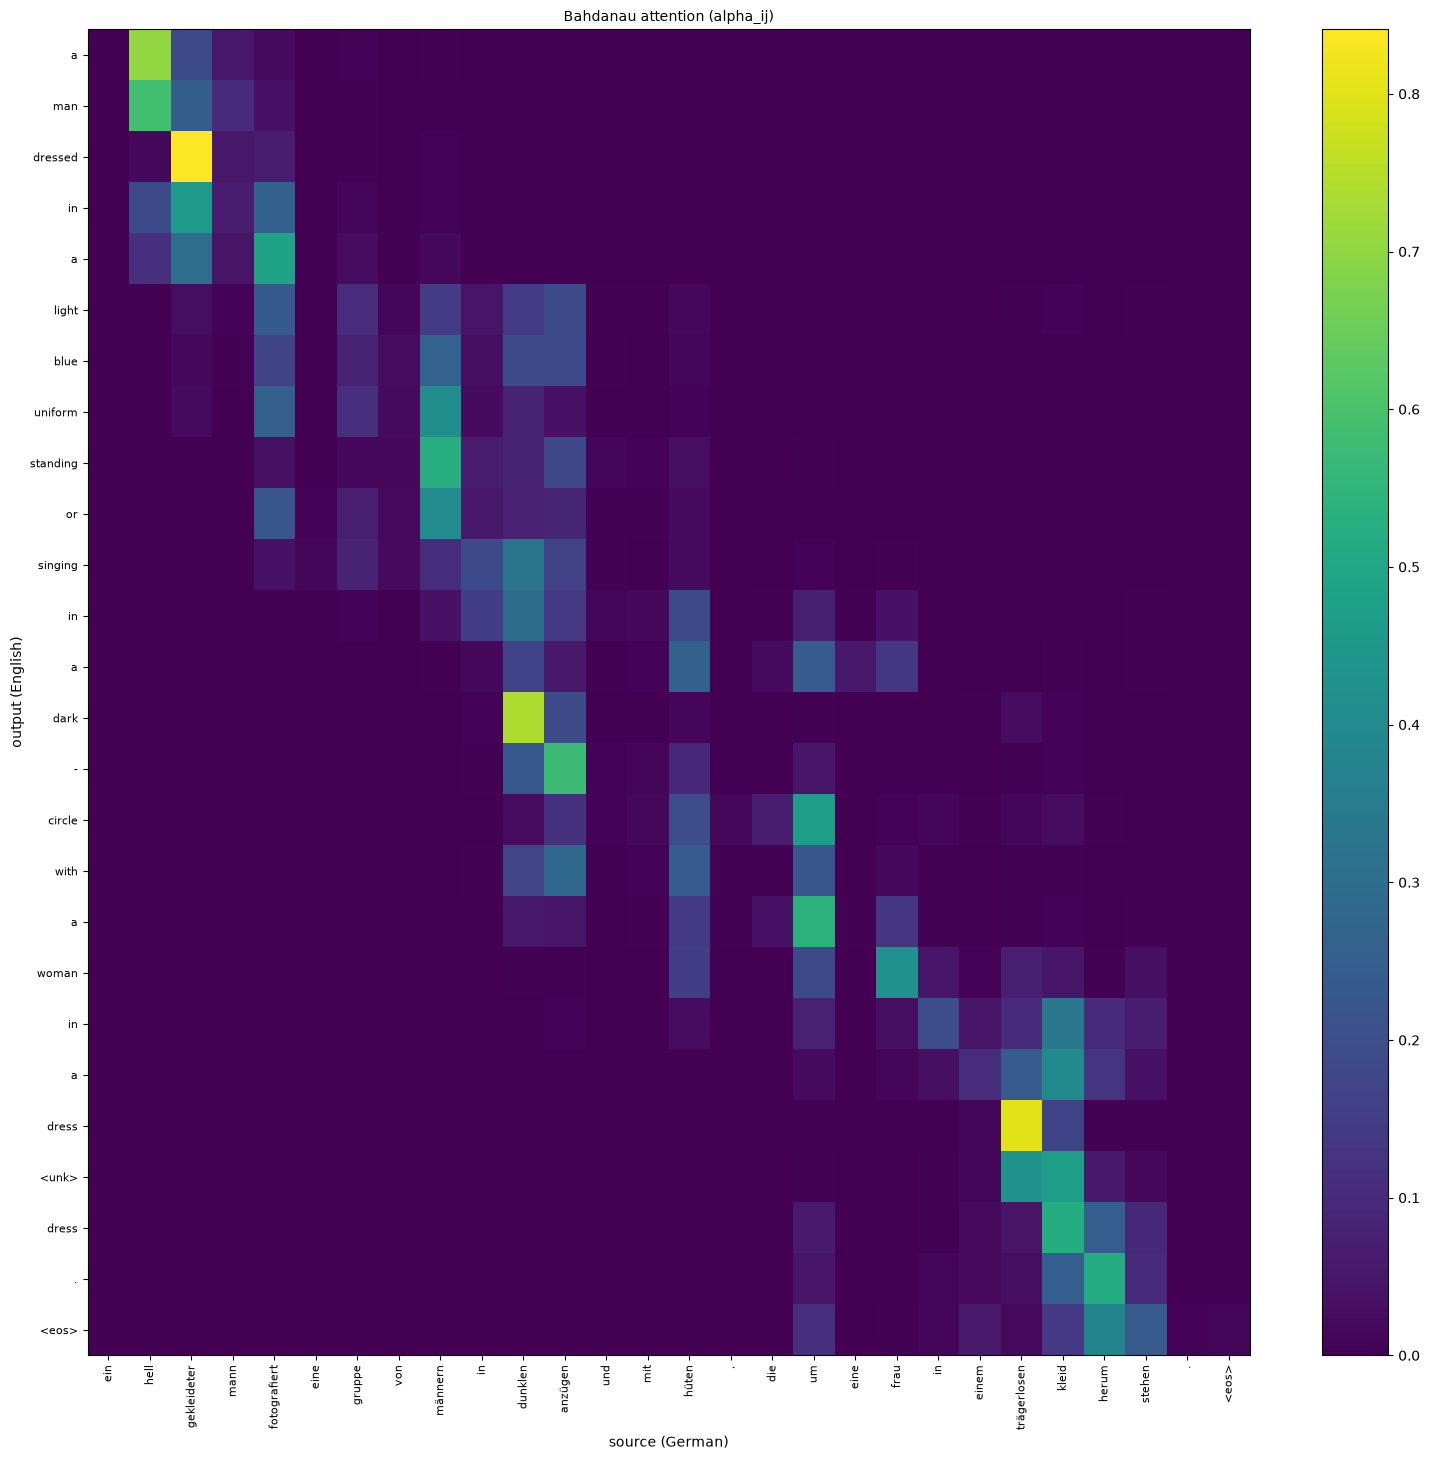

source: ein hell gekleideter mann fotografiert eine gruppe von männern in dunklen anzügen und mit hüten , die um eine frau in einem trägerlosen kleid herum stehen .
model : a man dressed in a light blue uniform standing or singing in a dark - circle with a woman in a dress <unk> dress . <eos>


In [23]:
def attention_map(model, index, head=0):
    source_ids, _, _ = test_dataset[index]
    source = torch.tensor([source_ids], device=DEVICE)
    source_pad = source.eq(PAD)
    ids, weights = w2.greedy_decode(model, source, source_pad,
                                    max_len=DECODE_MAX_LEN, return_attention=True)
    output_words = ids_to_tokens(ids[0])
    input_words = test_pairs[index][0] + ["<eos>"]
    rows = (output_words + ["<eos>"])[:weights.size(1)]
    return weights[0, :len(rows), :, :len(input_words)], rows, input_words


def draw_attention(matrix, rows, columns, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(0.45 * len(columns) + 3, 0.45 * len(rows) + 3))
    picture = ax.imshow(matrix, aspect="auto", cmap="viridis", vmin=0)
    ax.set_xticks(range(len(columns))); ax.set_xticklabels(columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=8)
    ax.set_xlabel("source (German)"); ax.set_ylabel("output (English)")
    ax.set_title(title, fontsize=10)
    return picture


EXAMPLE = 5
weights, rows, columns = attention_map(model, EXAMPLE)
picture = draw_attention(weights[:, 0].cpu().numpy(), rows, columns,
                         "Bahdanau attention (alpha_ij)")
plt.colorbar(picture); plt.tight_layout(); plt.show()

print("source:", " ".join(test_pairs[EXAMPLE][0]))
print("model :", " ".join(rows))

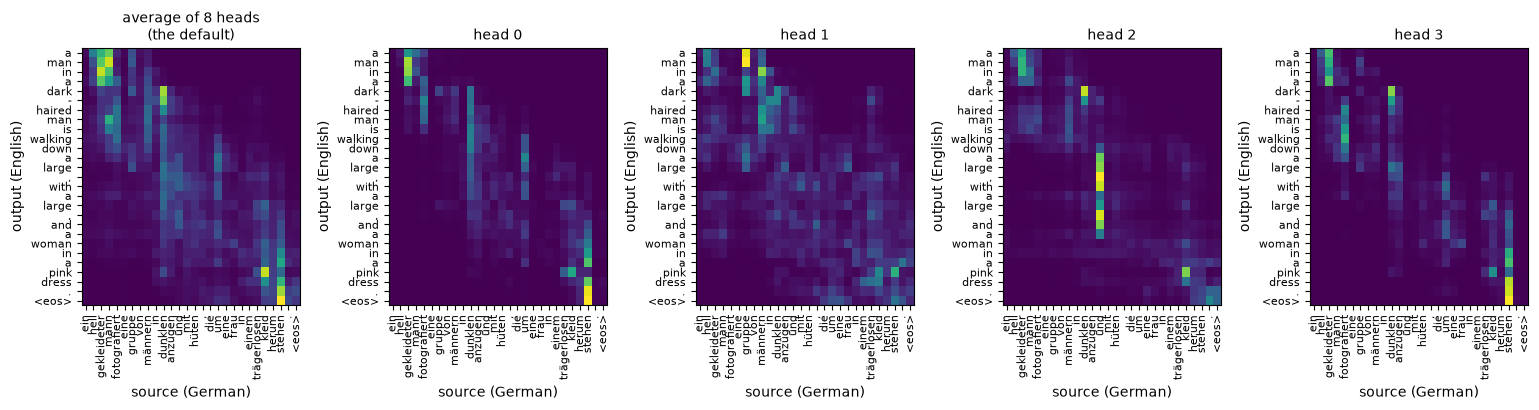

heads returned              : 8
mean |head - head average|  : 0.0256
largest |head - head average|: 0.6504

nn.MultiheadAttention returns the head AVERAGE unless you pass
average_attn_weights=False (the .py file passes it). That average is a
single picture built from several different distributions, and it equals
any one of them only when the heads agree - the two numbers above say how
far from agreement this model is. Week 2's alpha_ij is a single
distribution, so read one head, or set NUM_HEADS = 1 for this week and
leave several heads to week 3.


In [24]:
# Why the default of nn.MultiheadAttention is misleading for this week.
mha_model = next(r["model"] for r in experiments if r["attention"] == "mha")
mha_weights, mha_rows, mha_columns = attention_map(mha_model, EXAMPLE)
heads = mha_weights.size(1)

figure, axes = plt.subplots(1, min(heads, 4) + 1, figsize=(3.1 * (min(heads, 4) + 1), 4.2))
draw_attention(mha_weights.mean(1).cpu().numpy(), mha_rows, mha_columns,
               f"average of {heads} heads\n(the default)", axes[0])
for k in range(min(heads, 4)):
    draw_attention(mha_weights[:, k].cpu().numpy(), mha_rows, mha_columns,
                   f"head {k}", axes[k + 1])
plt.tight_layout(); plt.show()

deviation = (mha_weights - mha_weights.mean(dim=1, keepdim=True)).abs()
print(f"heads returned              : {heads}")
print(f"mean |head - head average|  : {deviation.mean().item():.4f}")
print(f"largest |head - head average|: {deviation.max().item():.4f}")
print()
print("nn.MultiheadAttention returns the head AVERAGE unless you pass")
print("average_attn_weights=False (the .py file passes it). That average is a")
print("single picture built from several different distributions, and it equals")
print("any one of them only when the heads agree - the two numbers above say how")
print("far from agreement this model is. Week 2's alpha_ij is a single")
print("distribution, so read one head, or set NUM_HEADS = 1 for this week and")
print("leave several heads to week 3.")

## 11. Save the model

In [25]:
save_path = Path("outputs_week02")
save_path.mkdir(exist_ok=True)
torch.save({"state_dict": model.state_dict(),
            "itos": itos,
            "config": {"attention": ATTENTION, "emb_dim": EMB_DIM, "hid_dim": HID_DIM,
                       "num_heads": NUM_HEADS, "vocab_size": VOCAB_SIZE},
            "test_bleu": bleu_raw},
           save_path / "seq2seq_attention_multi30k.pt")
print(f"saved -> {(save_path / 'seq2seq_attention_multi30k.pt').resolve()}")

saved -> /home/jovyan/lecture-advanceddeeplearning/outputs_week02/seq2seq_attention_multi30k.pt


## 12. Summary

| Item | Value |
|---|---|
| Dataset | Multi30k, German -> English |
| Model | bi-GRU encoder + GRU decoder, hand-written Bahdanau attention |
| Main metric | corpus BLEU-4 on `test_2016_flickr`, against the **raw** reference |

What to read out of each section (your numbers will differ from run to run):

1. Section 7 - compare `none` with the attention rows, and above all look at the
   length curve. The claim of the week is not "attention wins by X BLEU", it is
   "the plain encoder-decoder degrades with length and attention does not".
   That is Bahdanau's Figure 2, in miniature.
2. Section 7 - the differences *among* the score functions are small. They were
   small in the Luong paper too (one or two BLEU), so do not read a ranking out
   of a three-epoch run.
3. Section 7.3 - `concat` and `additive` are the same equation written two ways.
   This one is exact arithmetic, not an experiment.
4. Section 8 - reversing the source is expected to help the fixed-vector model
   more than the attention model. Check the two deltas the cell prints.
5. Section 9 - watch the average output length, not only BLEU: without length
   normalisation a wider beam finds shorter sentences.
6. Section 10 - `nn.MultiheadAttention` returns the head average by default, and
   an average of several distributions is not the single alpha_ij of week 2.

Note: BLEU depends on how the text was tokenized. Our simple word split is not
the same as the tokenizer used in published papers, so compare our numbers with
**week 3** (same data, same tokenizer) rather than with numbers from a paper.

## Try it yourself

1. Train for more epochs. When does the validation loss stop going down?
2. Set `MIN_FREQ = 1`. The vocabulary grows and `<unk>` almost disappears - does
   BLEU against the **raw** reference get better or worse, and why?
3. Raise `COMPARE_PAIRS` to the full training set and rerun section 7. Do the
   score functions separate more, or do they stay within a point of each other?
4. Implement **local attention** (`local-m`: only look at source positions
   `t-D .. t+D`). Start from `w2.LuongAttention` and add the window.
5. In section 9, try `length_norm=0.6` (the value used by several MT systems).
   Where does the average output length end up?
6. Look at the attention picture for a long sentence. Does the bright diagonal
   break where German and English word order differ?